In [226]:
import pandas as pd

dataset = pd.read_csv("C:/Users/mohan/OneDrive/Desktop/UMass Amhers MSCS/Spring 2026 - Machine Learning/Homework 1/HW1_CMPSCI_589_Spring2026_Supporting_Files/HW1_CMPSCI_589_Spring2026_Supporting_Files/datasets/wdbc.csv", header = None)

dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [228]:
import sklearn

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(dataset.iloc[:,0:30], dataset.iloc[:,30], train_size = 0.8, 
                                                    test_size = 0.2, shuffle = True)

# iloc[rows, columns] - Accesses rows and columns by their position
# shuffle - the data is shuffled before splitting

In [230]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_norm = scaler.fit_transform(x_train)
x_test_norm = scaler.transform(x_test)

In [232]:
import numpy as np

def knn_calculation(x_train_norm, y_train, X, k):

    distance = np.sqrt(np.sum((x_train_norm - X)**2, axis = 1))

    distance_sort = np.argsort(distance)[:k] 

    k_labels_indices = y_train[distance_sort]

    prediction = np.bincount(k_labels_indices).argmax()

    return prediction

In [234]:
k = 5

X = x_train_norm[0]

y_train_np = y_train.to_numpy()


true_label = y_train_np[0]

predicted_label = knn_calculation(x_train_norm, y_train_np, X, k)

print("True label:", true_label)
print("Predicted label:", predicted_label)

True label: 0
Predicted label: 0


In [236]:
y_train_np = y_train.to_numpy()

k = 5  

predictions_training = np.array([knn_calculation(x_train_norm, y_train_np, x_train_norm[i], k)
                        for i in range(len(x_train_norm))])

accuracy = np.mean(predictions_training == y_train)

print("Training Accuracy:", accuracy)

Training Accuracy: 0.978021978021978


In [238]:
import numpy as np

def knn_calculation_test(x_train_norm, y_train_np, X, k):

    distance = np.sqrt(np.sum((x_train_norm - X)**2, axis = 1))

    distance_sort = np.argsort(distance)[:k] 

    k_labels_indices = y_train[distance_sort]

    prediction = np.bincount(k_labels_indices).argmax()

    return prediction

In [240]:
k = 5

X = x_test_norm[0]

y_test_np = y_test.to_numpy()


true_label = y_test_np[0]

predicted_label = knn_calculation(x_train_norm, y_train_np, X, k)

print("True label:", true_label)
print("Predicted label:", predicted_label)

True label: 1
Predicted label: 1


In [242]:
y_test_np = y_test.to_numpy()

k = 5  

predictions_testing = np.array([knn_calculation(x_train_norm, y_train_np, x_test_norm[i], k)
                        for i in range(len(x_test_norm))])

accuracy = np.mean(predictions_testing == y_test)

print("Testing Accuracy:", accuracy)

Testing Accuracy: 0.956140350877193


In [244]:
from sklearn.preprocessing import StandardScaler

k_values = range(1, 52, 2)    #class range(start, stop, step) 

train_means = []
test_means = []
train_stds = [] 
test_stds = [] 

for k in k_values:

    train_accuracies = []
    test_accuracies = []

    for run in range(20):

        x_train, x_test, y_train, y_test = train_test_split(dataset.iloc[:,0:30], dataset.iloc[:,30], train_size = 0.8, test_size = 0.2, shuffle = True, random_state = run)

        # iloc[rows, columns] - Accesses rows and columns by their position
        # shuffle - the data is shuffled before splitting

        scaler = StandardScaler()  # creates an object named scaler from the StandardScaler class
        x_train_norm = scaler.fit_transform(x_train)  # fit_transform method replaces the original values with rescaled values
        x_test_norm = scaler.transform(x_test)
    
        y_train_np = y_train.to_numpy()
        y_test_np = y_test.to_numpy()
    
        predictions_training = np.array([knn_calculation(np.delete(x_train_norm, i, 0), np.delete(y_train_np, i, 0), x_train_norm[i], k) for i in range(len(x_train_norm))])
        train_accuracy = np.mean(predictions_training == y_train_np)    
        train_accuracies.append(train_accuracy)
    
        predictions_testing = np.array([knn_calculation(x_train_norm, y_train_np, x_test_norm[i], k) for i in range(len(x_test_norm))])
        test_accuracy = np.mean(predictions_testing == y_test_np)        
        test_accuracies.append(test_accuracy)
    
    train_means.append(np.mean(train_accuracies))
    test_means.append(np.mean(test_accuracies))

    train_stds.append(np.std(train_accuracies))
    test_stds.append(np.std(test_accuracies))

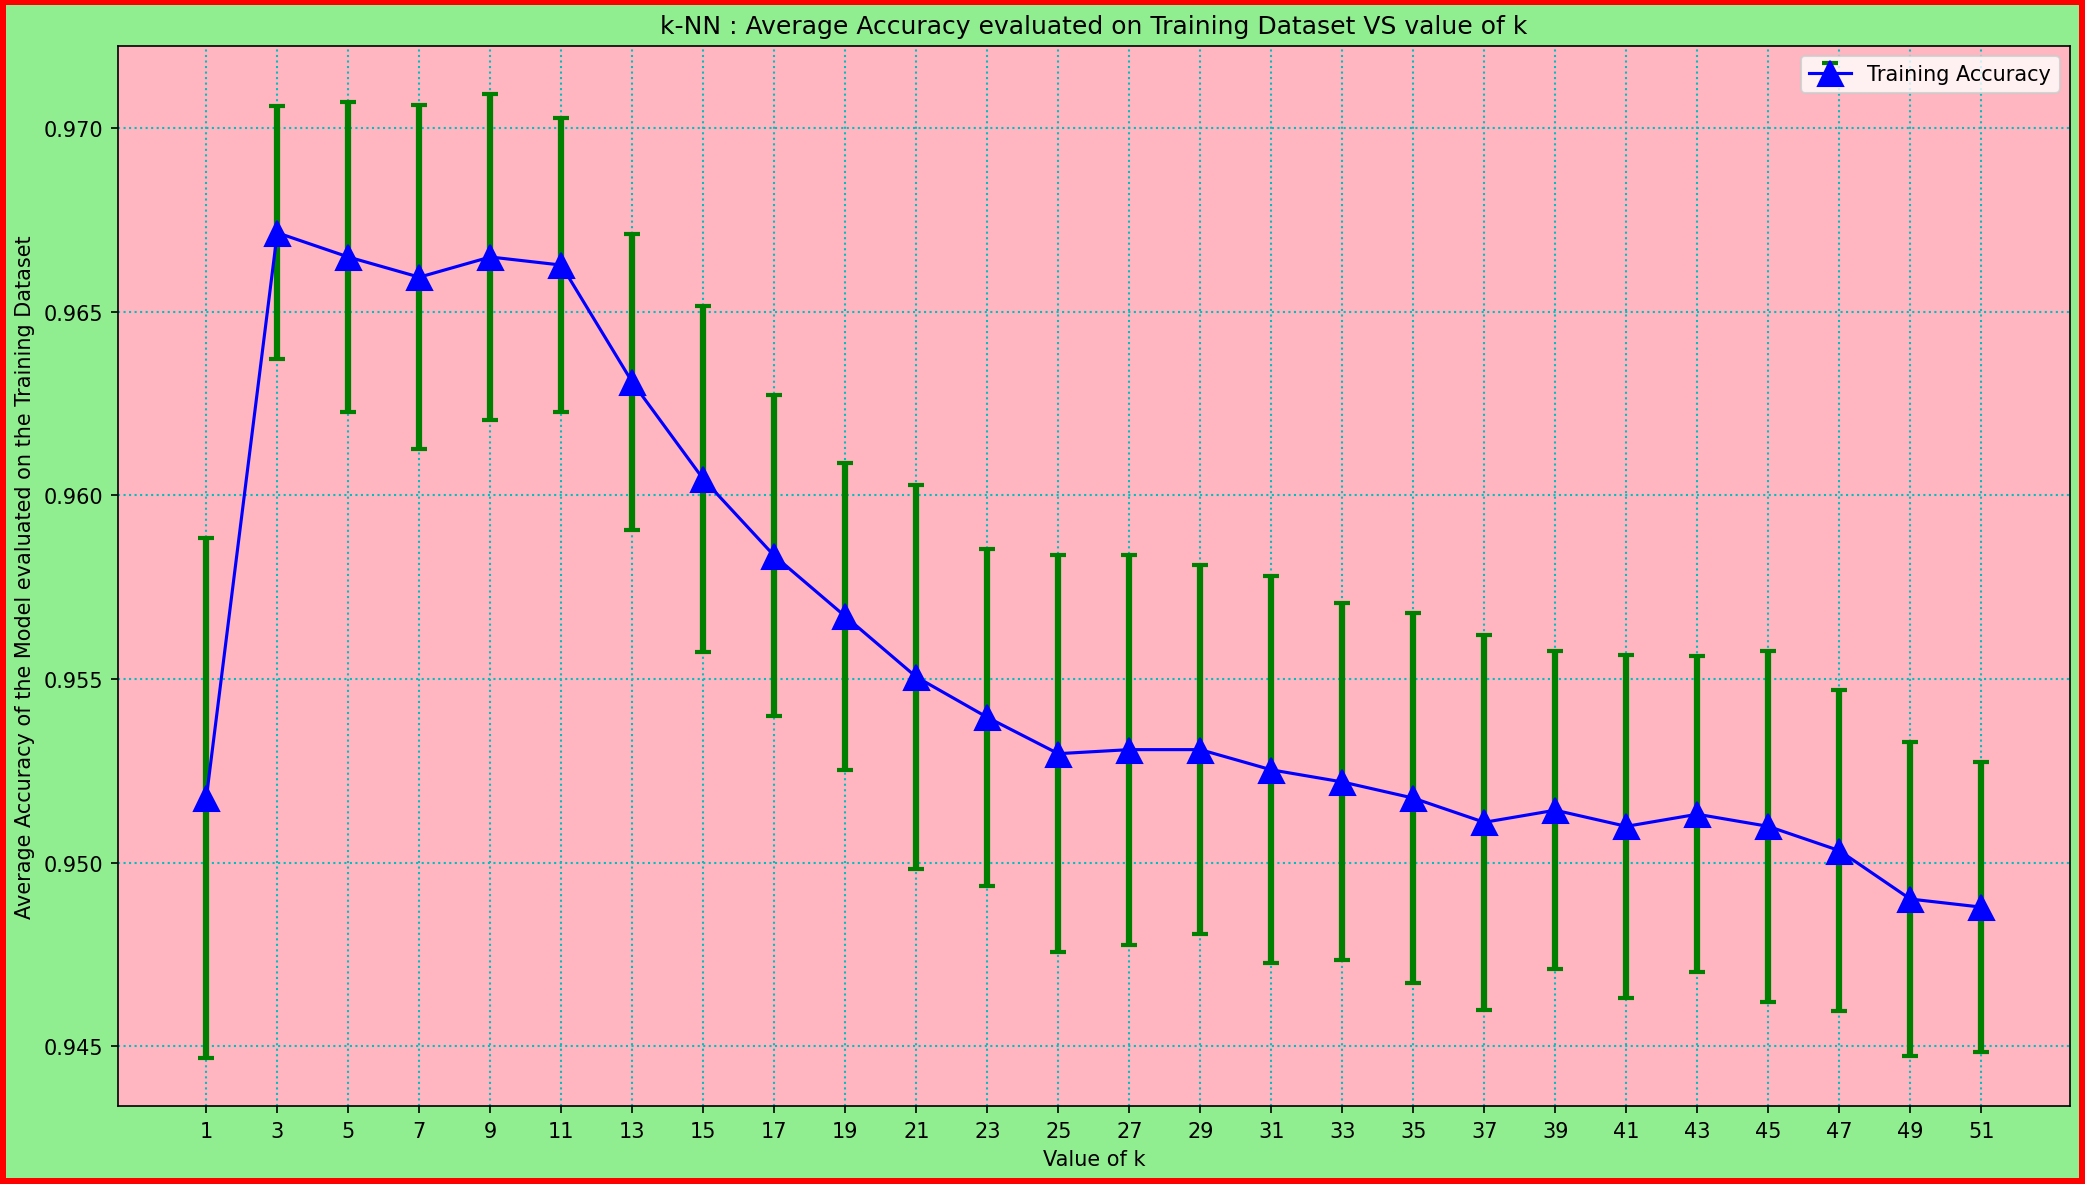

In [245]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8), dpi = 150.0, facecolor = 'lightgreen', edgecolor = 'red', linewidth = 5.0, frameon = True,
          layout = 'tight')


plt.errorbar(
    x = k_values,
    y = train_means,
    xerr = None,
    yerr = train_stds,
    fmt = '^-',
    label = 'Training Accuracy',
    markersize = 12.0,
    color = 'b',
    capsize = 4,
    capthick = 2,
    ecolor = 'g',
    elinewidth = 3.0,
    barsabove = False,
    errorevery = 1
)

plt.xticks(k_values)
plt.xlabel("Value of k")
plt.ylabel("Average Accuracy of the Model evaluated on the Training Dataset")
plt.title("k-NN : Average Accuracy evaluated on Training Dataset VS value of k")
plt.grid(True, axis = 'both', color = 'c',linestyle = ':', linewidth = 1.0, alpha = 1.0)
plt.legend()
plt.gca().set_facecolor('lightpink')
plt.savefig('Q1.1 K-NN Model Accuracy-Training set.png')

plt.show()

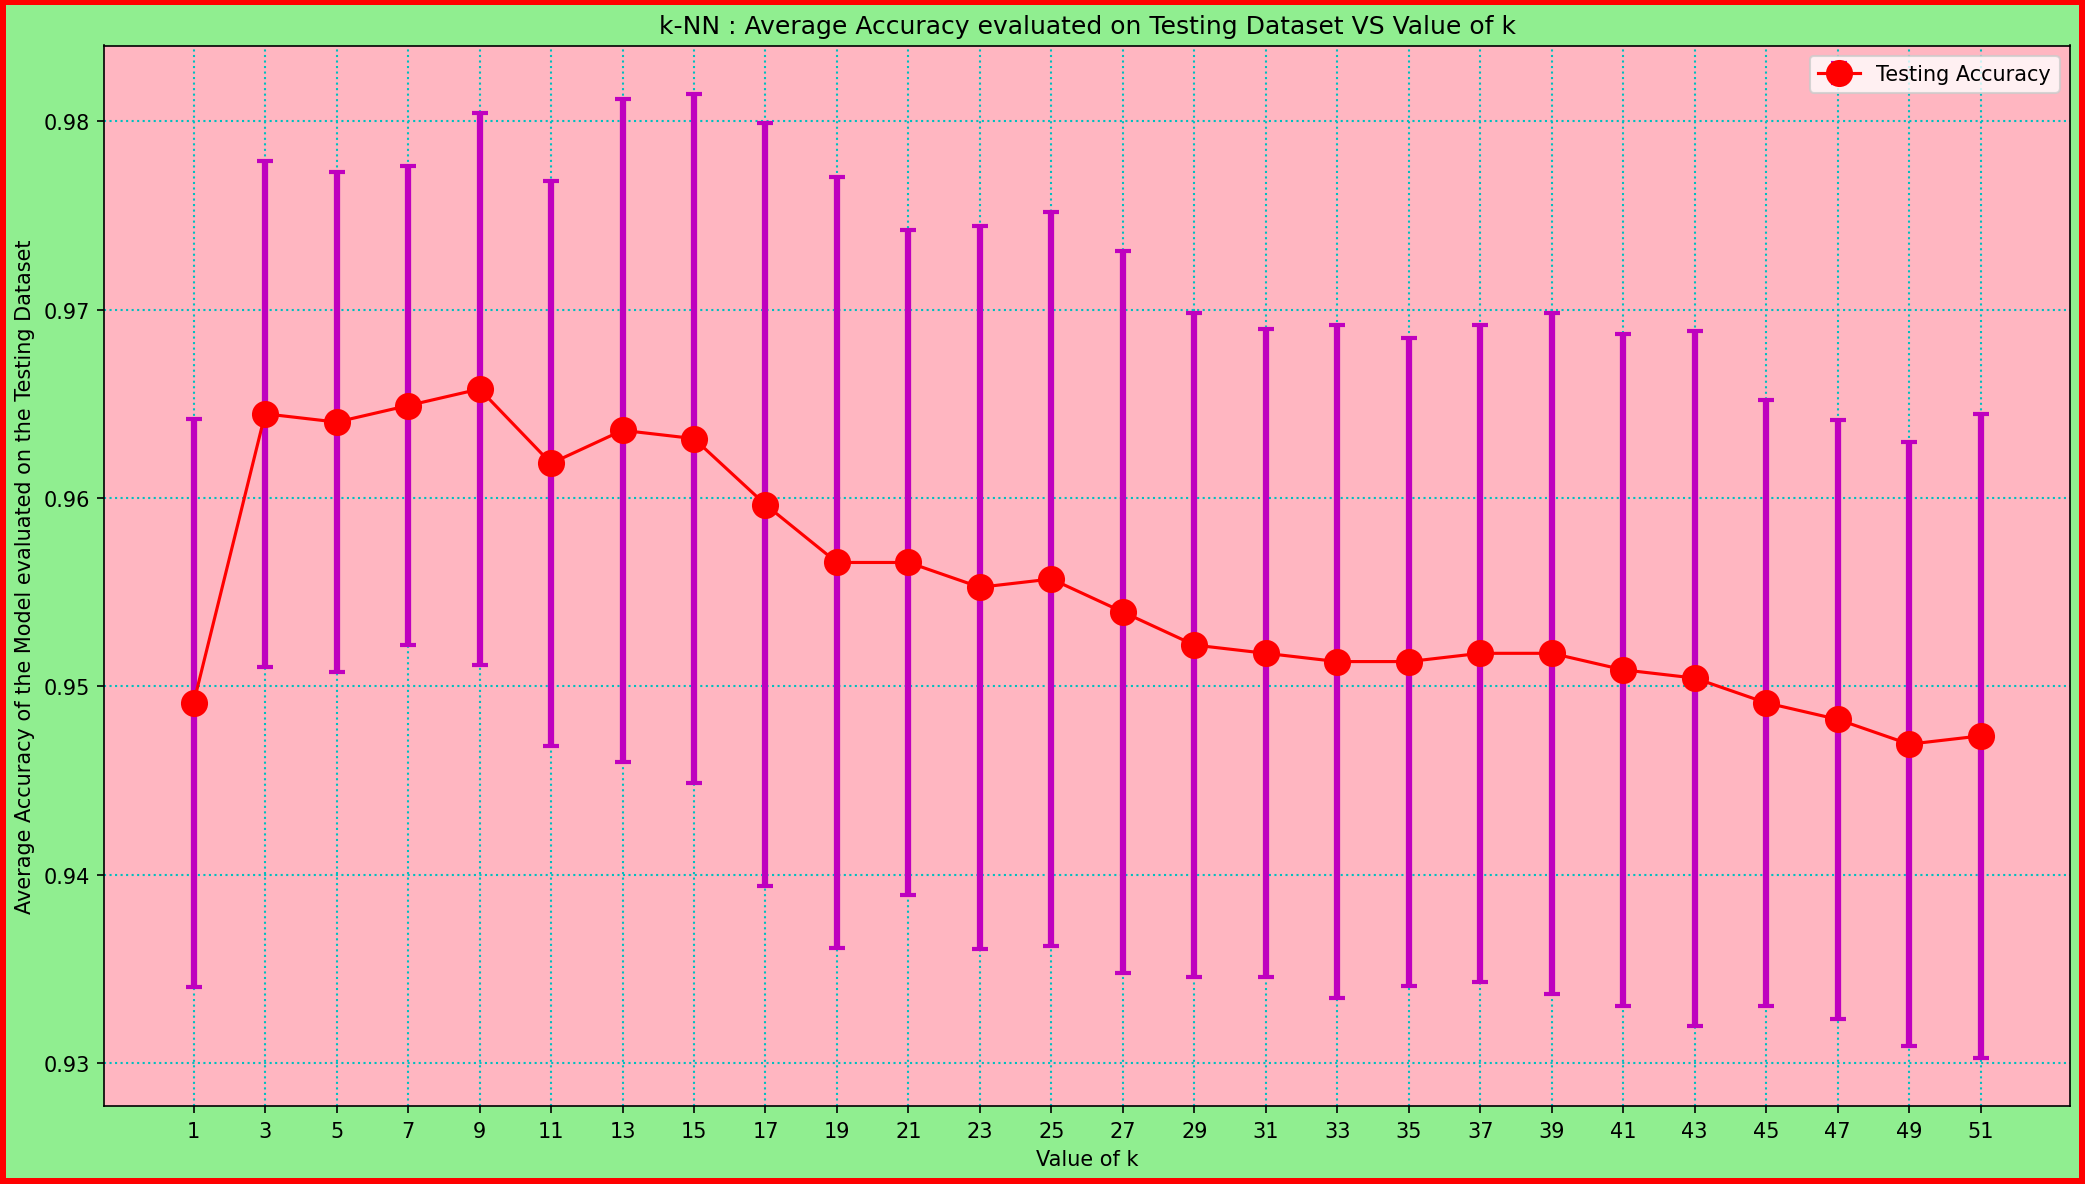

In [248]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8), dpi = 150.0, facecolor = 'lightgreen', edgecolor = 'red', linewidth = 5.0, frameon = True,
          layout = 'tight')


plt.errorbar(
    x = k_values,
    y = test_means,
    xerr = None,
    yerr = test_stds,
    fmt = 'o-',
    label = 'Testing Accuracy',
    markersize = 12.0,
    color = 'r',
    capsize = 4,
    capthick = 2,
    ecolor = 'm',
    elinewidth = 3.0,
    barsabove = False,
    errorevery = 1
)

plt.xticks(k_values)
plt.xlabel("Value of k")
plt.ylabel("Average Accuracy of the Model evaluated on the Testing Dataset")
plt.title("k-NN : Average Accuracy evaluated on Testing Dataset VS Value of k")
plt.grid(True, axis = 'both', color = 'c',linestyle = ':', linewidth = 1.0, alpha = 1.0)
plt.legend()
plt.gca().set_facecolor('lightpink')
plt.savefig('Q1.2 K-NN Model Accuracy-Testing set.png')

plt.show()

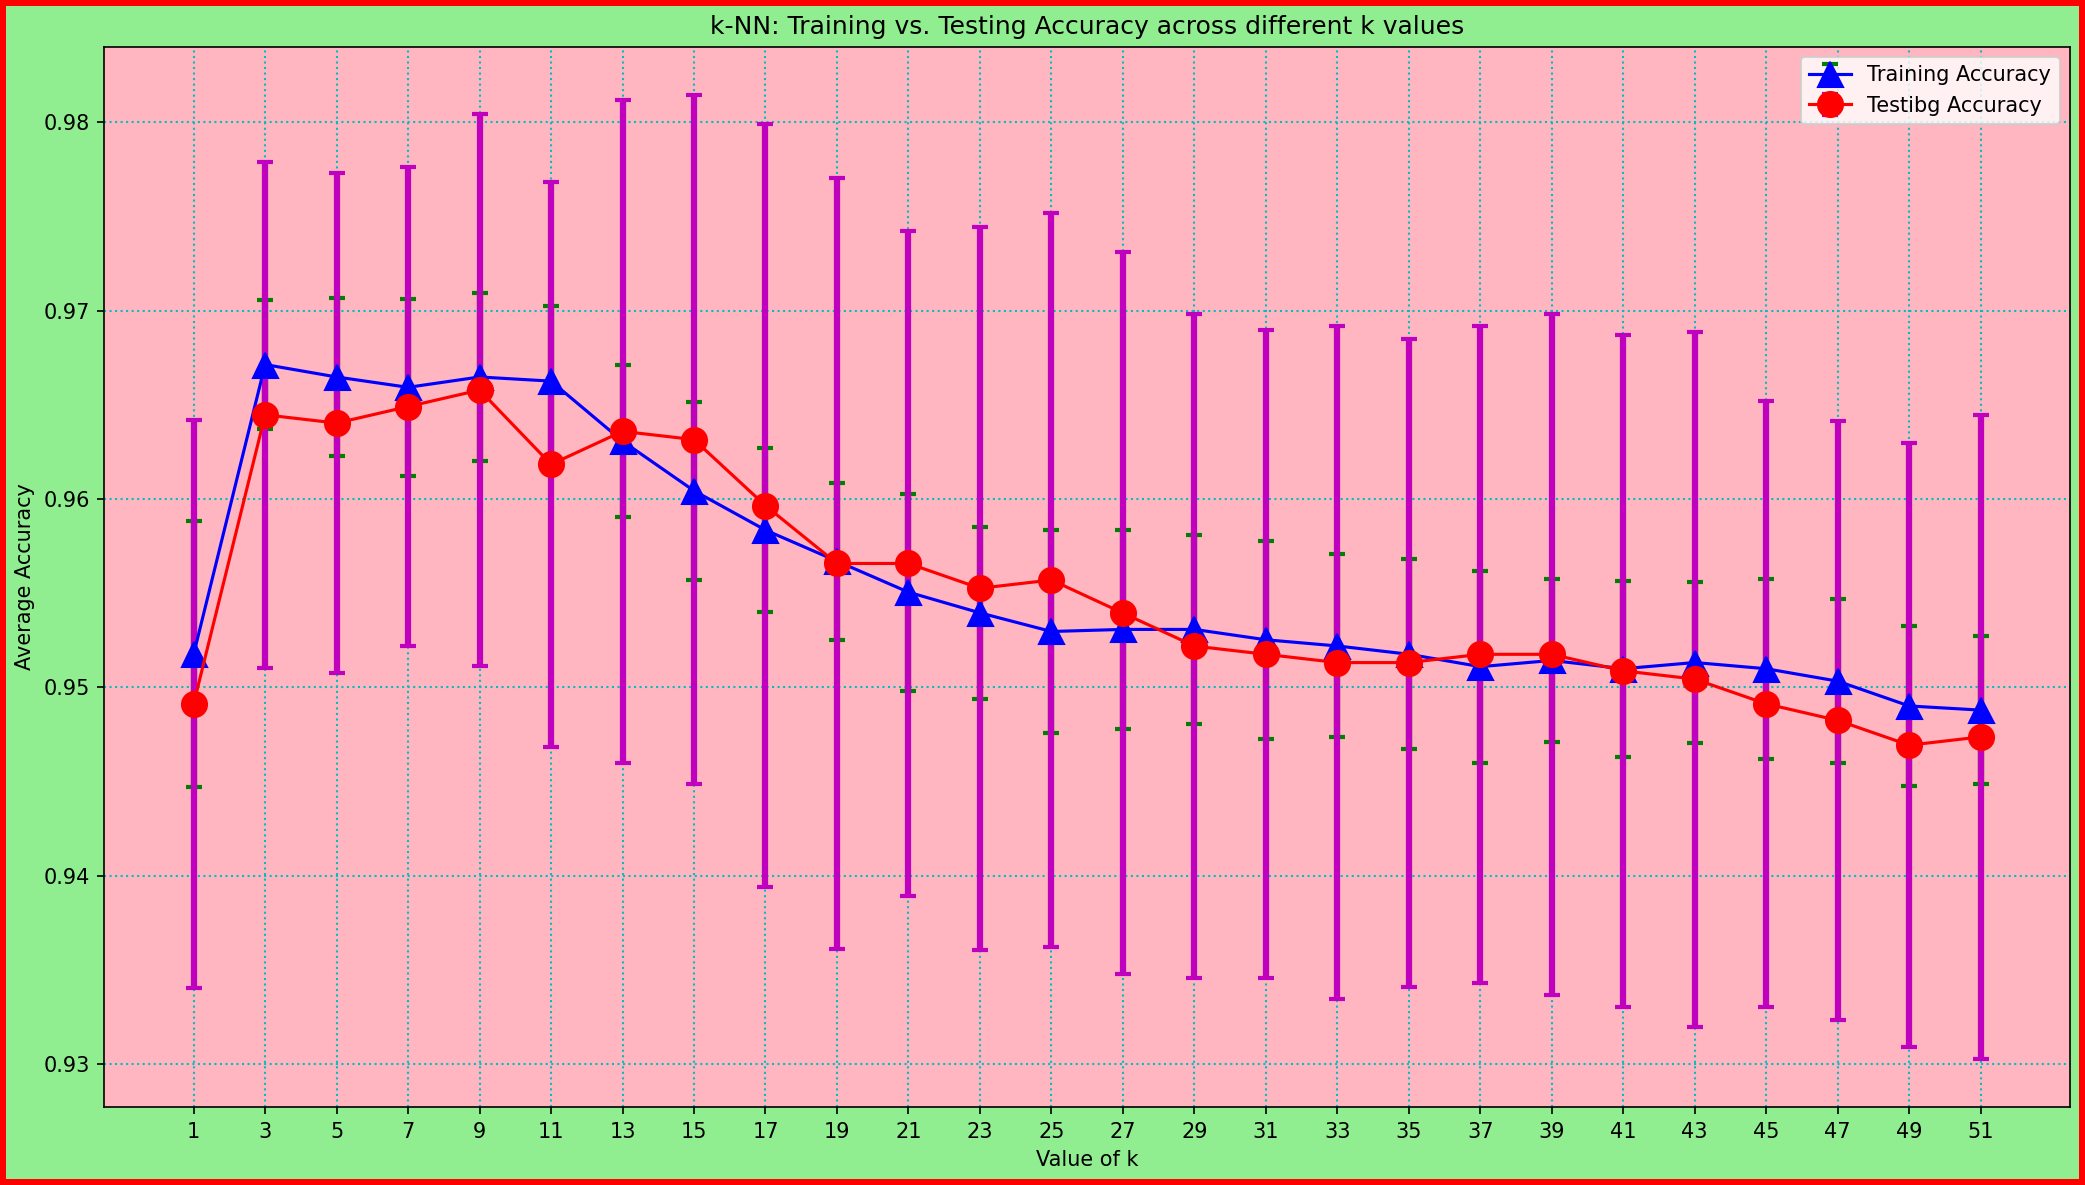

In [252]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8), dpi=150.0, facecolor='lightgreen', edgecolor='red', linewidth=5.0, frameon=True, 
           layout='tight')

plt.errorbar(
    x=k_values,
    y=train_means,
    xerr = None,
    yerr=train_stds,
    fmt='^-',
    label = 'Training Accuracy',
    markersize=12.0,
    color='b',
    capsize=4,
    capthick = 2,
    ecolor='g',
    elinewidth = 3.0,
    barsabove = False,
    errorevery = 1
)


plt.errorbar(
    x=k_values,
    y=test_means,
    xerr = None,
    yerr=test_stds,
    fmt='o-',
    label = 'Testibg Accuracy',
    markersize=12.0,
    color='r',
    capsize = 4,
    capthick = 2,
    ecolor='m',
    elinewidth = 3.0,
    barsabove = False,
    errorevery = 1
)

plt.xticks(k_values)
plt.xlabel("Value of k")
plt.ylabel("Average Accuracy")
plt.title("k-NN: Training vs. Testing Accuracy across different k values")
plt.grid(True, axis='both', color='c', linestyle=':', linewidth=1.0, alpha=1.0)
plt.legend()

plt.gca().set_facecolor('lightpink')
plt.savefig('Q1.3 K-NN Model Accuracy-Training vs Testing set.pdf')
plt.show()

In [260]:
k_values = range(1, 52, 2)

train_means = []
test_means = []
train_stds = [] 
test_stds = [] 

for k in k_values:

    train_accuracies = []
    test_accuracies = []

    for run in range(20):

        x_train, x_test, y_train, y_test = train_test_split(
            dataset.iloc[:,0:30],
            dataset.iloc[:,30],
            train_size=0.8,
            test_size=0.2,
            shuffle=True,
            random_state=run
        )

        # Convert to numpy
        x_train_np = x_train.to_numpy()
        x_test_np = x_test.to_numpy()
        y_train_np = y_train.to_numpy()
        y_test_np = y_test.to_numpy()

        # ---- Training Accuracy ----
        
        predictions_training = np.array([
            knn_calculation(np.delete(x_train_np, i, 0), np.delete(y_train_np, i, 0), x_train_np[i], k)
            for i in range(len(x_train_np))
        ])

        train_accuracy = np.mean(predictions_training == y_train_np)
        train_accuracies.append(train_accuracy)

        # ---- Testing Accuracy ----
        predictions_testing = np.array([
            knn_calculation(x_train_np, y_train_np, x_test_np[i], k)
            for i in range(len(x_test_np))
        ])

        test_accuracy = np.mean(predictions_testing == y_test_np)
        test_accuracies.append(test_accuracy)

    train_means.append(np.mean(train_accuracies))
    test_means.append(np.mean(test_accuracies))

    train_stds.append(np.std(train_accuracies))
    test_stds.append(np.std(test_accuracies))

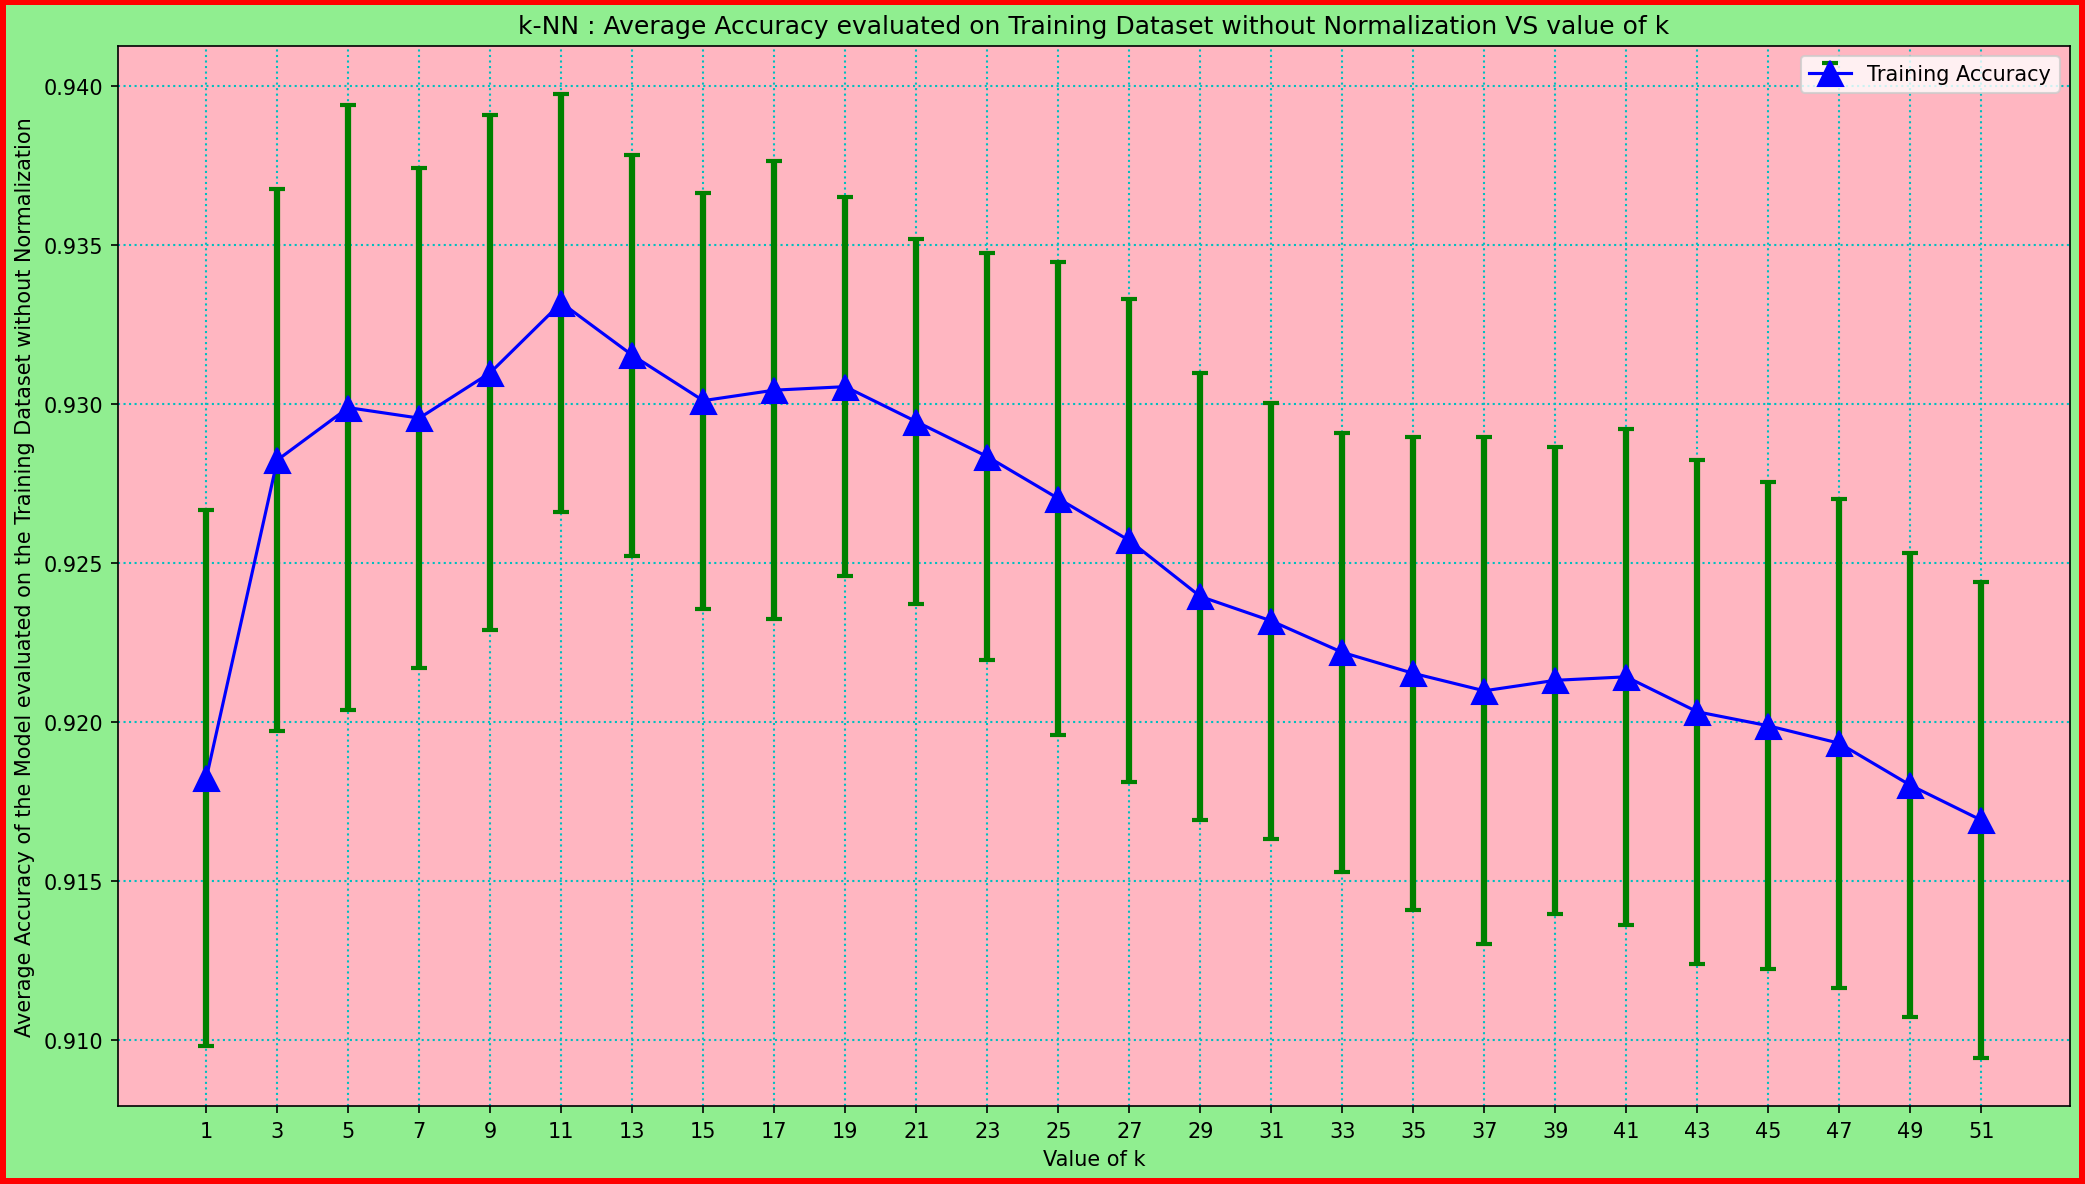

In [262]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8), dpi = 150.0, facecolor = 'lightgreen', edgecolor = 'red', linewidth = 5.0, frameon = True,
          layout = 'tight')


plt.errorbar(
    x = k_values,
    y = train_means,
    xerr = None,
    yerr = train_stds,
    fmt = '^-',
    label = 'Training Accuracy',
    markersize = 12.0,
    color = 'b',
    capsize = 4,
    capthick = 2,
    ecolor = 'g',
    elinewidth = 3.0,
    barsabove = False,
    errorevery = 1
)

plt.xticks(k_values)
plt.xlabel("Value of k")
plt.ylabel("Average Accuracy of the Model evaluated on the Training Dataset without Normalization")
plt.title("k-NN : Average Accuracy evaluated on Training Dataset without Normalization VS value of k")
plt.grid(True, axis = 'both', color = 'c',linestyle = ':', linewidth = 1.0, alpha = 1.0)
plt.gca().set_facecolor('lightpink')
plt.legend()

plt.show()

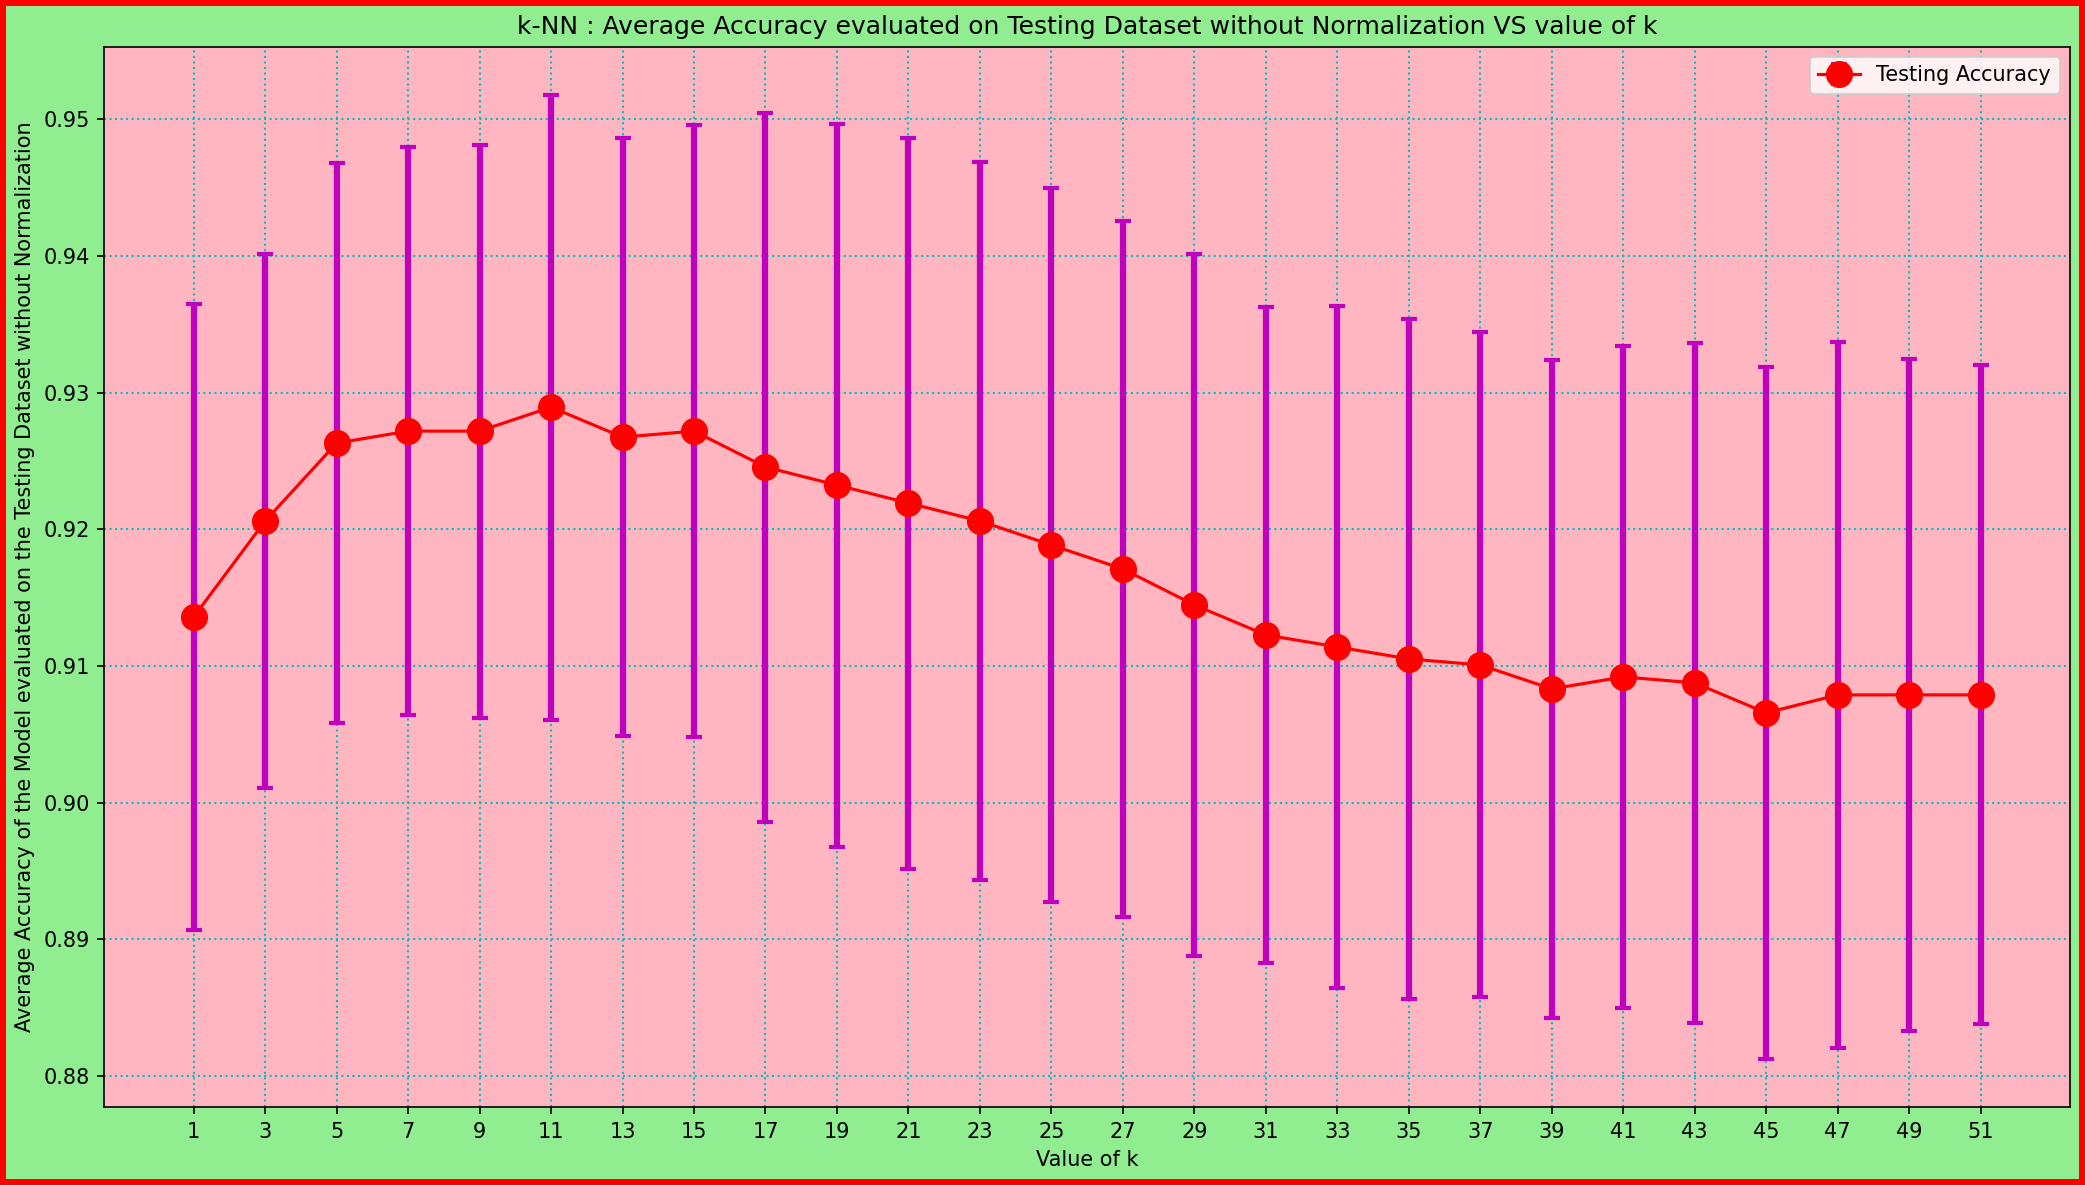

In [266]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8), dpi = 150.0, facecolor = 'lightgreen', edgecolor = 'red', linewidth = 5.0, frameon = True,
          layout = 'tight')


plt.errorbar(
    x = k_values,
    y = test_means,
    xerr = None,
    yerr = test_stds,
    fmt = 'o-',
    label = 'Testing Accuracy',
    markersize = 12.0,
    color = 'r',
    capsize = 4,
    capthick = 2,
    ecolor = 'm',
    elinewidth = 3.0,
    barsabove = False,
    errorevery = 1
)

plt.xticks(k_values)
plt.xlabel("Value of k")
plt.ylabel("Average Accuracy of the Model evaluated on the Testing Dataset without Normalization")
plt.title("k-NN : Average Accuracy evaluated on Testing Dataset without Normalization VS value of k")
plt.grid(True, axis = 'both', color = 'c',linestyle = ':', linewidth = 1.0, alpha = 1.0)
plt.gca().set_facecolor('lightpink')
plt.savefig('Q1.6 K-NN Model Accuracy - Testing set without Normalization.pdf')
plt.legend()

plt.show()

In [300]:
import pandas as pd

car_dataset = pd.read_csv("C:/Users/mohan/OneDrive/Desktop/UMass Amhers MSCS/Spring 2026 - Machine Learning/Homework 1/HW1_CMPSCI_589_Spring2026_Supporting_Files/HW1_CMPSCI_589_Spring2026_Supporting_Files/datasets/car.csv")

car_dataset.head()

,buying_price,maintenance_price,number_doors,capacity,luggage_boot_size,safety_level,class
0,very_high,very_high,two,two,small,low,unacceptable
1,very_high,very_high,two,two,small,medium,unacceptable
2,very_high,very_high,two,two,small,high,unacceptable
3,very_high,very_high,two,two,medium,low,unacceptable
4,very_high,very_high,two,two,medium,medium,unacceptable


In [42]:
import sklearn

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(car_dataset.iloc[:,0:6], car_dataset.iloc[:,6], train_size = 0.8, 
                                                    test_size = 0.2, shuffle = True)

# iloc[rows, columns] - Accesses rows and columns by their position
# shuffle - the data is shuffled before splitting

In [302]:
car_dataset.iloc[:,6].value_counts()

class
unacceptable    1210
acceptable       384
good              69
very_good         65
Name: count, dtype: int64

In [77]:
len(car_dataset)

1728

In [21]:
import numpy as np

numerator = car_dataset.iloc[:,6].value_counts()

denominator = len(car_dataset)

print(numerator/denominator)


class
unacceptable    0.700231
acceptable      0.222222
good            0.039931
very_good       0.037616
Name: count, dtype: float64


In [23]:
import numpy as np

Entropy_car_dataset = -0.700231 * (np.log2 (0.700231)) - 0.222222 * (np.log2 (0.222222)) - 0.039931 * (np.log2 (0.039931)) - 0.037616 * (np.log2 (0.037616));

print(Entropy_car_dataset)

1.2057435322733685


In [101]:
car_dataset.iloc[:,0].value_counts()

buying_price
very_high    432
high         432
medium       432
low          432
Name: count, dtype: int64

In [165]:
buying_price_numerator_1 = car_dataset.iloc[:,6][car_dataset.iloc[:,0] == "very_high"].value_counts()
buying_price_numerator_2 = car_dataset.iloc[:,6][car_dataset.iloc[:,0] == "high"].value_counts()
buying_price_numerator_3 = car_dataset.iloc[:,6][car_dataset.iloc[:,0] == "medium"].value_counts()
buying_price_numerator_4 = car_dataset.iloc[:,6][car_dataset.iloc[:,0] == "low"].value_counts()

buying_price_denominator_1 = len(car_dataset[car_dataset.iloc[:,0] == "very_high"])
buying_price_denominator_2 = len(car_dataset[car_dataset.iloc[:,0] == "high"])
buying_price_denominator_3 = len(car_dataset[car_dataset.iloc[:,0] == "medium"])
buying_price_denominator_4 = len(car_dataset[car_dataset.iloc[:,0] == "low"])

print(buying_price_numerator_1)
print(buying_price_numerator_2)
print(buying_price_numerator_3)
print(buying_price_numerator_4)

print(buying_price_denominator_1)
print(buying_price_denominator_2)
print(buying_price_denominator_3)
print(buying_price_denominator_4)

print(buying_price_numerator_1/buying_price_denominator_1)
print(buying_price_numerator_2/buying_price_denominator_2)
print(buying_price_numerator_3/buying_price_denominator_3)
print(buying_price_numerator_4/buying_price_denominator_4)

class
unacceptable    360
acceptable       72
Name: count, dtype: int64
class
unacceptable    324
acceptable      108
Name: count, dtype: int64
class
unacceptable    268
acceptable      115
very_good        26
good             23
Name: count, dtype: int64
class
unacceptable    258
acceptable       89
good             46
very_good        39
Name: count, dtype: int64
432
432
432
432
class
unacceptable    0.833333
acceptable      0.166667
Name: count, dtype: float64
class
unacceptable    0.75
acceptable      0.25
Name: count, dtype: float64
class
unacceptable    0.620370
acceptable      0.266204
very_good       0.060185
good            0.053241
Name: count, dtype: float64
class
unacceptable    0.597222
acceptable      0.206019
good            0.106481
very_good       0.090278
Name: count, dtype: float64


In [153]:
Entropy_car_dataset_buying_price_1 = -0.833333 * (np.log2 (0.833333)) - 0.166667 * (np.log2 (0.166667))
Entropy_car_dataset_buying_price_2 = -0.75 * (np.log2 (0.75)) - 0.25 * (np.log2 (0.25))
Entropy_car_dataset_buying_price_3 = -0.620370 * (np.log2 (0.620370)) - 0.266204 * (np.log2 (0.266204)) - 0.060185 * (np.log2 (0.060185)) - 0.053241 * (np.log2 (0.053241))
Entropy_car_dataset_buying_price_4 = -0.597222 * (np.log2 (0.597222)) - 0.206019 * (np.log2 (0.206019)) - 0.106481 * (np.log2 (0.106481)) - 0.090278 * (np.log2 (0.090278))


print(Entropy_car_dataset_buying_price_1)
print(Entropy_car_dataset_buying_price_2)
print(Entropy_car_dataset_buying_price_3)
print(Entropy_car_dataset_buying_price_4)

Average_Entropy_car_dataset_buying_price = (((buying_price_denominator_1) / len(car_dataset)) * Entropy_car_dataset_buying_price_1) + (((buying_price_denominator_2) / len(car_dataset)) * Entropy_car_dataset_buying_price_2) + (((buying_price_denominator_3) / len(car_dataset)) * Entropy_car_dataset_buying_price_3) + (((buying_price_denominator_4) / len(car_dataset)) * Entropy_car_dataset_buying_price_4)

print(Average_Entropy_car_dataset_buying_price)

Information_Gain_buying_price = Entropy_car_dataset - Average_Entropy_car_dataset_buying_price

print(Information_Gain_buying_price)

0.6500231956238088
0.8112781244591328
1.4048959910171115
1.5709722703506264
1.1092923953626699
0.09645113691069862


In [155]:
car_dataset.iloc[:,1].value_counts()

maintenance_price
very_high    432
high         432
medium       432
low          432
Name: count, dtype: int64

In [157]:
maintenance_price_numerator_1 = car_dataset.iloc[:,6][car_dataset.iloc[:,1] == "very_high"].value_counts()
maintenance_price_numerator_2 = car_dataset.iloc[:,6][car_dataset.iloc[:,1] == "high"].value_counts()
maintenance_price_numerator_3 = car_dataset.iloc[:,6][car_dataset.iloc[:,1] == "medium"].value_counts()
maintenance_price_numerator_4 = car_dataset.iloc[:,6][car_dataset.iloc[:,1] == "low"].value_counts()

maintenance_price_denominator_1 = len(car_dataset[car_dataset.iloc[:,1] == "very_high"])
maintenance_price_denominator_2 = len(car_dataset[car_dataset.iloc[:,1] == "high"])
maintenance_price_denominator_3 = len(car_dataset[car_dataset.iloc[:,1] == "medium"])
maintenance_price_denominator_4 = len(car_dataset[car_dataset.iloc[:,1] == "low"])

print(maintenance_price_numerator_1)
print(maintenance_price_numerator_2)
print(maintenance_price_numerator_3)
print(maintenance_price_numerator_4)

print(maintenance_price_denominator_1)
print(maintenance_price_denominator_2)
print(maintenance_price_denominator_3)
print(maintenance_price_denominator_4)

print(maintenance_price_numerator_1/maintenance_price_denominator_1)
print(maintenance_price_numerator_2/maintenance_price_denominator_2)
print(maintenance_price_numerator_3/maintenance_price_denominator_3)
print(maintenance_price_numerator_4/maintenance_price_denominator_4)

class
unacceptable    360
acceptable       72
Name: count, dtype: int64
class
unacceptable    314
acceptable      105
very_good        13
Name: count, dtype: int64
class
unacceptable    268
acceptable      115
very_good        26
good             23
Name: count, dtype: int64
class
unacceptable    268
acceptable       92
good             46
very_good        26
Name: count, dtype: int64
432
432
432
432
class
unacceptable    0.833333
acceptable      0.166667
Name: count, dtype: float64
class
unacceptable    0.726852
acceptable      0.243056
very_good       0.030093
Name: count, dtype: float64
class
unacceptable    0.620370
acceptable      0.266204
very_good       0.060185
good            0.053241
Name: count, dtype: float64
class
unacceptable    0.620370
acceptable      0.212963
good            0.106481
very_good       0.060185
Name: count, dtype: float64


In [161]:
Entropy_car_dataset_maintenance_price_1 = -0.833333 * (np.log2 (0.833333)) - 0.166667 * (np.log2 (0.166667))
Entropy_car_dataset_maintenance_price_2 = -0.726852 * (np.log2 (0.726852)) - 0.243056 * (np.log2 (0.243056)) - 0.030093 * (np.log2 (0.030093))
Entropy_car_dataset_maintenance_price_3 = -0.620370 * (np.log2 (0.620370)) - 0.266204 * (np.log2 (0.266204)) - 0.060185 * (np.log2 (0.060185)) - 0.053241 * (np.log2 (0.053241))
Entropy_car_dataset_maintenance_price_4 = -0.620370 * (np.log2 (0.620370)) - 0.212963 * (np.log2 (0.212963)) - 0.106481 * (np.log2 (0.106481)) - 0.060185 * (np.log2 (0.060185))


print(Entropy_car_dataset_maintenance_price_1)
print(Entropy_car_dataset_maintenance_price_2)
print(Entropy_car_dataset_maintenance_price_3)
print(Entropy_car_dataset_maintenance_price_4)

Average_Entropy_car_dataset_maintenance_price = (((maintenance_price_denominator_1) / len(car_dataset)) * Entropy_car_dataset_maintenance_price_1) + (((buying_price_denominator_2) / len(car_dataset)) * Entropy_car_dataset_maintenance_price_2) + (((buying_price_denominator_3) / len(car_dataset)) * Entropy_car_dataset_maintenance_price_3) + (((buying_price_denominator_4) / len(car_dataset)) * Entropy_car_dataset_maintenance_price_4)

print(Average_Entropy_car_dataset_maintenance_price)

Information_Gain_maintenance_price = Entropy_car_dataset - Average_Entropy_car_dataset_maintenance_price

print(Information_Gain_maintenance_price)

0.6500231956238088
0.9826381427980893
1.4048959910171115
1.4905927489575752
1.1320375195991463
0.07370601267422217


In [167]:
car_dataset.iloc[:,2].value_counts()

number_doors
two          432
three        432
four         432
5_or_more    432
Name: count, dtype: int64

In [169]:
number_doors_numerator_1 = car_dataset.iloc[:,6][car_dataset.iloc[:,2] == "two"].value_counts()
number_doors_numerator_2 = car_dataset.iloc[:,6][car_dataset.iloc[:,2] == "three"].value_counts()
number_doors_numerator_3 = car_dataset.iloc[:,6][car_dataset.iloc[:,2] == "four"].value_counts()
number_doors_numerator_4 = car_dataset.iloc[:,6][car_dataset.iloc[:,2] == "5_or_more"].value_counts()

number_doors_denominator_1 = len(car_dataset[car_dataset.iloc[:,2] == "two"])
number_doors_denominator_2 = len(car_dataset[car_dataset.iloc[:,2] == "three"])
number_doors_denominator_3 = len(car_dataset[car_dataset.iloc[:,2] == "four"])
number_doors_denominator_4 = len(car_dataset[car_dataset.iloc[:,2] == "5_or_more"])

print(number_doors_numerator_1)
print(number_doors_numerator_2)
print(number_doors_numerator_3)
print(number_doors_numerator_4)

print(number_doors_denominator_1)
print(number_doors_denominator_2)
print(number_doors_denominator_3)
print(number_doors_denominator_4)

print(number_doors_numerator_1/number_doors_denominator_1)
print(number_doors_numerator_2/number_doors_denominator_2)
print(number_doors_numerator_3/number_doors_denominator_3)
print(number_doors_numerator_4/number_doors_denominator_4)

class
unacceptable    326
acceptable       81
good             15
very_good        10
Name: count, dtype: int64
class
unacceptable    300
acceptable       99
good             18
very_good        15
Name: count, dtype: int64
class
unacceptable    292
acceptable      102
very_good        20
good             18
Name: count, dtype: int64
class
unacceptable    292
acceptable      102
very_good        20
good             18
Name: count, dtype: int64
432
432
432
432
class
unacceptable    0.754630
acceptable      0.187500
good            0.034722
very_good       0.023148
Name: count, dtype: float64
class
unacceptable    0.694444
acceptable      0.229167
good            0.041667
very_good       0.034722
Name: count, dtype: float64
class
unacceptable    0.675926
acceptable      0.236111
very_good       0.046296
good            0.041667
Name: count, dtype: float64
class
unacceptable    0.675926
acceptable      0.236111
very_good       0.046296
good            0.041667
Name: count, dtype: float64


In [171]:
Entropy_car_dataset_number_doors_1 = -0.754630 * (np.log2 (0.754630)) - 0.187500 * (np.log2 (0.187500)) - 0.034722 * (np.log2 (0.034722)) - 0.023148 * (np.log2 (0.023148))
Entropy_car_dataset_number_doors_2 = -0.694444 * (np.log2 (0.694444)) - 0.229167 * (np.log2 (0.229167)) - 0.041667 * (np.log2 (0.041667)) - 0.034722 * (np.log2 (0.034722))
Entropy_car_dataset_number_doors_3 = -0.675926 * (np.log2 (0.675926)) - 0.236111 * (np.log2 (0.236111)) - 0.046296 * (np.log2 (0.046296)) - 0.053241 * (np.log2 (0.053241))
Entropy_car_dataset_number_doors_4 = -0.675926 * (np.log2 (0.675926)) - 0.236111 * (np.log2 (0.236111)) - 0.046296 * (np.log2 (0.046296)) - 0.041667 * (np.log2 (0.041667))


print(Entropy_car_dataset_number_doors_1)
print(Entropy_car_dataset_number_doors_2)
print(Entropy_car_dataset_number_doors_3)
print(Entropy_car_dataset_number_doors_4)

Average_Entropy_car_dataset_number_doors = (((number_doors_denominator_1) / len(car_dataset)) * Entropy_car_dataset_number_doors_1) + (((number_doors_denominator_2) / len(car_dataset)) * Entropy_car_dataset_number_doors_2) + (((number_doors_denominator_3) / len(car_dataset)) * Entropy_car_dataset_number_doors_3) + (((number_doors_denominator_4) / len(car_dataset)) * Entropy_car_dataset_number_doors_4)

print(Average_Entropy_car_dataset_number_doors)

Information_Gain_number_doors = Entropy_car_dataset - Average_Entropy_car_dataset_number_doors

print(Information_Gain_number_doors)

1.0534138527921908
1.2118006466076428
1.3041413570903826
1.269902879340365
1.2098146839576454
-0.0040711516842768525


In [304]:
import numpy as np

def entropy(column_name):
# definition for entropy calculation, the parameter used is the column name
    
    counts = column_name.value_counts(normalize = True) 
    # value_counts = returns the count of each of the unique values in the series
    # normalize = If True, returns the counts as a percentage of the total rather than the actual counts

    entropy = 0

    for count in counts:
        entropy -= (count * np.log2(count))

    return entropy

In [306]:
car_dataset["class"].value_counts(normalize = True)
# car_dataset["class"] = picks only the class column from the car_dataset

class
unacceptable    0.700231
acceptable      0.222222
good            0.039931
very_good       0.037616
Name: proportion, dtype: float64

In [308]:
# Entropy calculation of the original car_dataset 
A = entropy(car_dataset["class"])
print("The entropy of the original dataset:", A)

The entropy of the original dataset: 1.2057409700121753


In [310]:
# List of Attributes to be tested
Attribute_List = car_dataset.drop(columns=["class"],inplace = False).columns.tolist()
# drop(params) = drops the column that are specified by the column parameter
# parameter 1 = columns = list of columns to be dropped
# parameter 2 = inplace = True makes the change directly to the database

In [312]:
print(Attribute_List)

['buying_price', 'maintenance_price', 'number_doors', 'capacity', 'luggage_boot_size', 'safety_level']


In [314]:
def average_entropy(dataframe, feature, column_name = "class"):

    TOTAL = len(dataframe)  # len() = Return the length (the number of items) of an object.
    AVG_entropy = 0

    for value in dataframe[feature].unique():
    # unique() = Returns the unique value in selected column

        subset = dataframe[dataframe[feature] == value]

        weight = len(subset) / TOTAL  # Computes |D_j| / |D| = proportion of instances in partition D_j after splitting on attribute A
        
        subset_entropy = entropy(subset[column_name]) # Computes the entropy of the subset corresponding to a specific value of the selected attribute

        #print(value, weight, subset_entropy)

        AVG_entropy += weight * subset_entropy
        # Accumulates |D_j| / |D| * I(D_j) to compute Info_A(D), the average entropy after splitting on attribute A

    return AVG_entropy

In [316]:
A = average_entropy(car_dataset, "buying_price")
print("Average Entropy of the car dataset:", A)

Average Entropy of the car dataset: 1.1092920008425613


In [318]:
def information_gain(dataframe,column_name,feature):

    Entropy_of_Dataset = entropy(dataframe[column_name])
    Average_Entropy_of_Partition = average_entropy(dataframe, feature)

    Information_Gain = (Entropy_of_Dataset - Average_Entropy_of_Partition)

    return Information_Gain

In [320]:
Info_Gain = information_gain(car_dataset, "class", "buying_price")
print("information gain", Info_Gain)

information gain 0.09644896916961399


In [322]:
Info_Gain = {}  # Initialize an empty dictionary to store Information Gain values
for attribute in Attribute_List:
    Info_Gain[attribute] = information_gain(car_dataset, "class", attribute) 
    # Compute Information Gain for the current attribute and store it in the dictionary using the attribute name as the key
    print("Information Gain for", attribute, "is", Info_Gain[attribute])

Information Gain for buying_price is 0.09644896916961399
Information Gain for maintenance_price is 0.07370394692148596
Information Gain for number_doors is 0.004485716626632108
Information Gain for capacity is 0.2196629633399082
Information Gain for luggage_boot_size is 0.030008141247605424
Information Gain for safety_level is 0.262184356554264


In [324]:
print(Info_Gain)

{'buying_price': 0.09644896916961399, 'maintenance_price': 0.07370394692148596, 'number_doors': 0.004485716626632108, 'capacity': 0.2196629633399082, 'luggage_boot_size': 0.030008141247605424, 'safety_level': 0.262184356554264}


In [326]:
Best_Feature = pd.Series(Info_Gain).sort_values(ascending=False).index[0]
# pd.Series = Convert dictionary to pandas Series, sort features by Information Gain in descending order,
# and select the feature with the highest Information Gain
print(Best_Feature)

safety_level


In [328]:
def best_feature(dataframe, column_name, features):
    if not features:
        return None
        
    Info_Gain = {}  # Initialize an empty dictionary to store Information Gain values
   
    for attribute in features:
        Info_Gain[attribute] = information_gain(dataframe, column_name, attribute) 
        # Compute Information Gain for the current attribute and store it in the dictionary using the attribute name as the key
        
        # print("Information Gain for", attribute, "is", Info_Gain[attribute])

    if not Info_Gain:
        return None
        
    Best_Feature = pd.Series(Info_Gain).sort_values(ascending=False).index[0]
    # pd.Series = Convert dictionary to pandas Series, sort features by Information Gain in descending order,
    # and select the feature with the highest Information Gain
    # print(Best_Feature)
    return Best_Feature

In [330]:
best = best_feature(car_dataset, "class", Attribute_List)
print(best)

safety_level


In [332]:
# Function used to return the majority class label in the dataframe target column
def majority_class(dataframe, column_name):
    counts = dataframe[column_name].value_counts()
    majority = counts.sort_values(ascending=False).index[0]
    
    return majority

In [334]:
maj = majority_class(car_dataset, "class")
print(maj)

unacceptable


In [336]:
def build_tree(dataframe, column_name, features):

    # If all instances in belong to the same class, Define node as a leaf node labeled with y and return it
    if dataframe[column_name].nunique() == 1:  # nunique() - returns the number of unique values in a column
        return {"is_leaf": True, "label": dataframe[column_name].iloc[0]}

    #  If there are no more attributes that can be tested, Define node as a leaf node labeled with the majority class in , and return it
    if len(features) == 0:
        return {"is_leaf": True, "label": majority_class(dataframe, column_name)}

    node_majority = majority_class(dataframe, column_name)

    best = best_feature(dataframe, column_name, features)

    node = {
        "is_leaf": False,
        "feature": best,
        "children": {},
        "majority": node_majority
    }
    # Outer dictionary creates the decision node using the best feature,
    # inner empty dictionary will store the branches (subtrees) for each feature value

    remaining_features = features.copy()  #  copy() - returns a shallow copy of the object
    remaining_features.remove(best)

    for value in dataframe[best].unique():
        subset = dataframe[dataframe[best] == value]

        if len(subset) == 0:
            node["children"][value] = {"is_leaf": True, "label": node_majority}
        else:
            node["children"][value] = build_tree(subset, column_name, remaining_features)
    
    return node

In [338]:
tree = build_tree(car_dataset, "class", Attribute_List.copy())

In [340]:
def predict_one(tree, row):
    if tree["is_leaf"]: 
        return tree["label"]

    feature = tree["feature"]
    value = row[feature]

        # unknown value
    if value not in tree["children"]:
        return tree.get("majority", None)

    return predict_one(tree["children"][value], row)

def predict_df(tree, dataframe):
    return dataframe.apply(lambda r: predict_one(tree, r), axis=1)

def accuracy(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)
    correct = sum(yt == yp for yt, yp in zip(y_true, y_pred))
    return correct / len(y_true)

In [354]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def run_100_histograms(dataframe, column_name = 'class', test_size=0.2, runs=100, seed=42):
    features = [c for c in dataframe.columns if c != column_name]

    train_accs = []
    test_accs = []

    for i in range(runs):
        train_df, test_df = train_test_split(dataframe, test_size = test_size, shuffle = True, random_state = seed + i)

        tree = build_tree(train_df, column_name, features.copy())

        train_pred = predict_df(tree, train_df[features])
        test_pred = predict_df(tree, test_df[features])

        train_accs.append(accuracy(train_df[column_name].values, train_pred))
        test_accs.append(accuracy(test_df[column_name].values, test_pred))


# Histogram for Training Accuracy
    plt.figure(figsize=(14,8), 
               dpi = 150.0, 
               facecolor = 'lightgreen', 
               edgecolor = 'red', 
               linewidth = 5.0, 
               frameon = True,
               layout = 'tight')
    
    plt.hist(train_accs, 
             bins = 5, 
             range = (0.9, 1.1), 
             bottom = None, 
             histtype = 'bar', 
             align = 'mid', 
             orientation = 'vertical', 
             color = 'red',
             label = 'Training Set', 
             stacked = True)
    
    plt.xlabel("Accuracy Score")
    plt.ylabel("Frequency with 100 experiments/training processes")
    plt.title("Accuracy distribution over training data")
    plt.grid(True, axis = 'both', color = 'c',linestyle = ':', linewidth = 2.0, alpha = 1.0)
    #plt.gca().set_facecolor('lightblue')
    plt.savefig('Q2.1 training_accuracy_histogram.png')
    plt.legend()
    plt.show()

    # Histogram for Testing Accuracy
    plt.figure(figsize=(14,8), 
               dpi = 150.0, 
               facecolor = 'lightgreen', 
               edgecolor = 'red', 
               linewidth = 5.0, 
               frameon = True,
               layout = 'tight')
    
    plt.hist(test_accs, 
             bins = 15, 
             range = (0.88, 0.97), 
             bottom = None, 
             histtype = 'bar', 
             align = 'mid', 
             orientation = 'vertical', 
             color = 'green',
             label = 'Testing Set', 
             stacked = True)
    plt.xlabel("Accuracy Score")
    plt.ylabel("Frequency with 100 experiments/testing processes")
    plt.title("Accuracy distribution over testing data")
    plt.grid(True, axis = 'both', color = 'c',linestyle = ':', linewidth = 2.0, alpha = 1.0)
    #plt.gca().set_facecolor('lightblue')
    plt.savefig('Q2.2 testing_accuracy_histogram.png')
    plt.legend()
    plt.show()


    print(f"Total training accuracies collected: {len(train_accs)}")
    if len(train_accs) > 0:
        print(f"First 5 results: {train_accs[:5]}")
        print(f"Type of data: {type(train_accs[0])}")

    return train_accs, test_accs

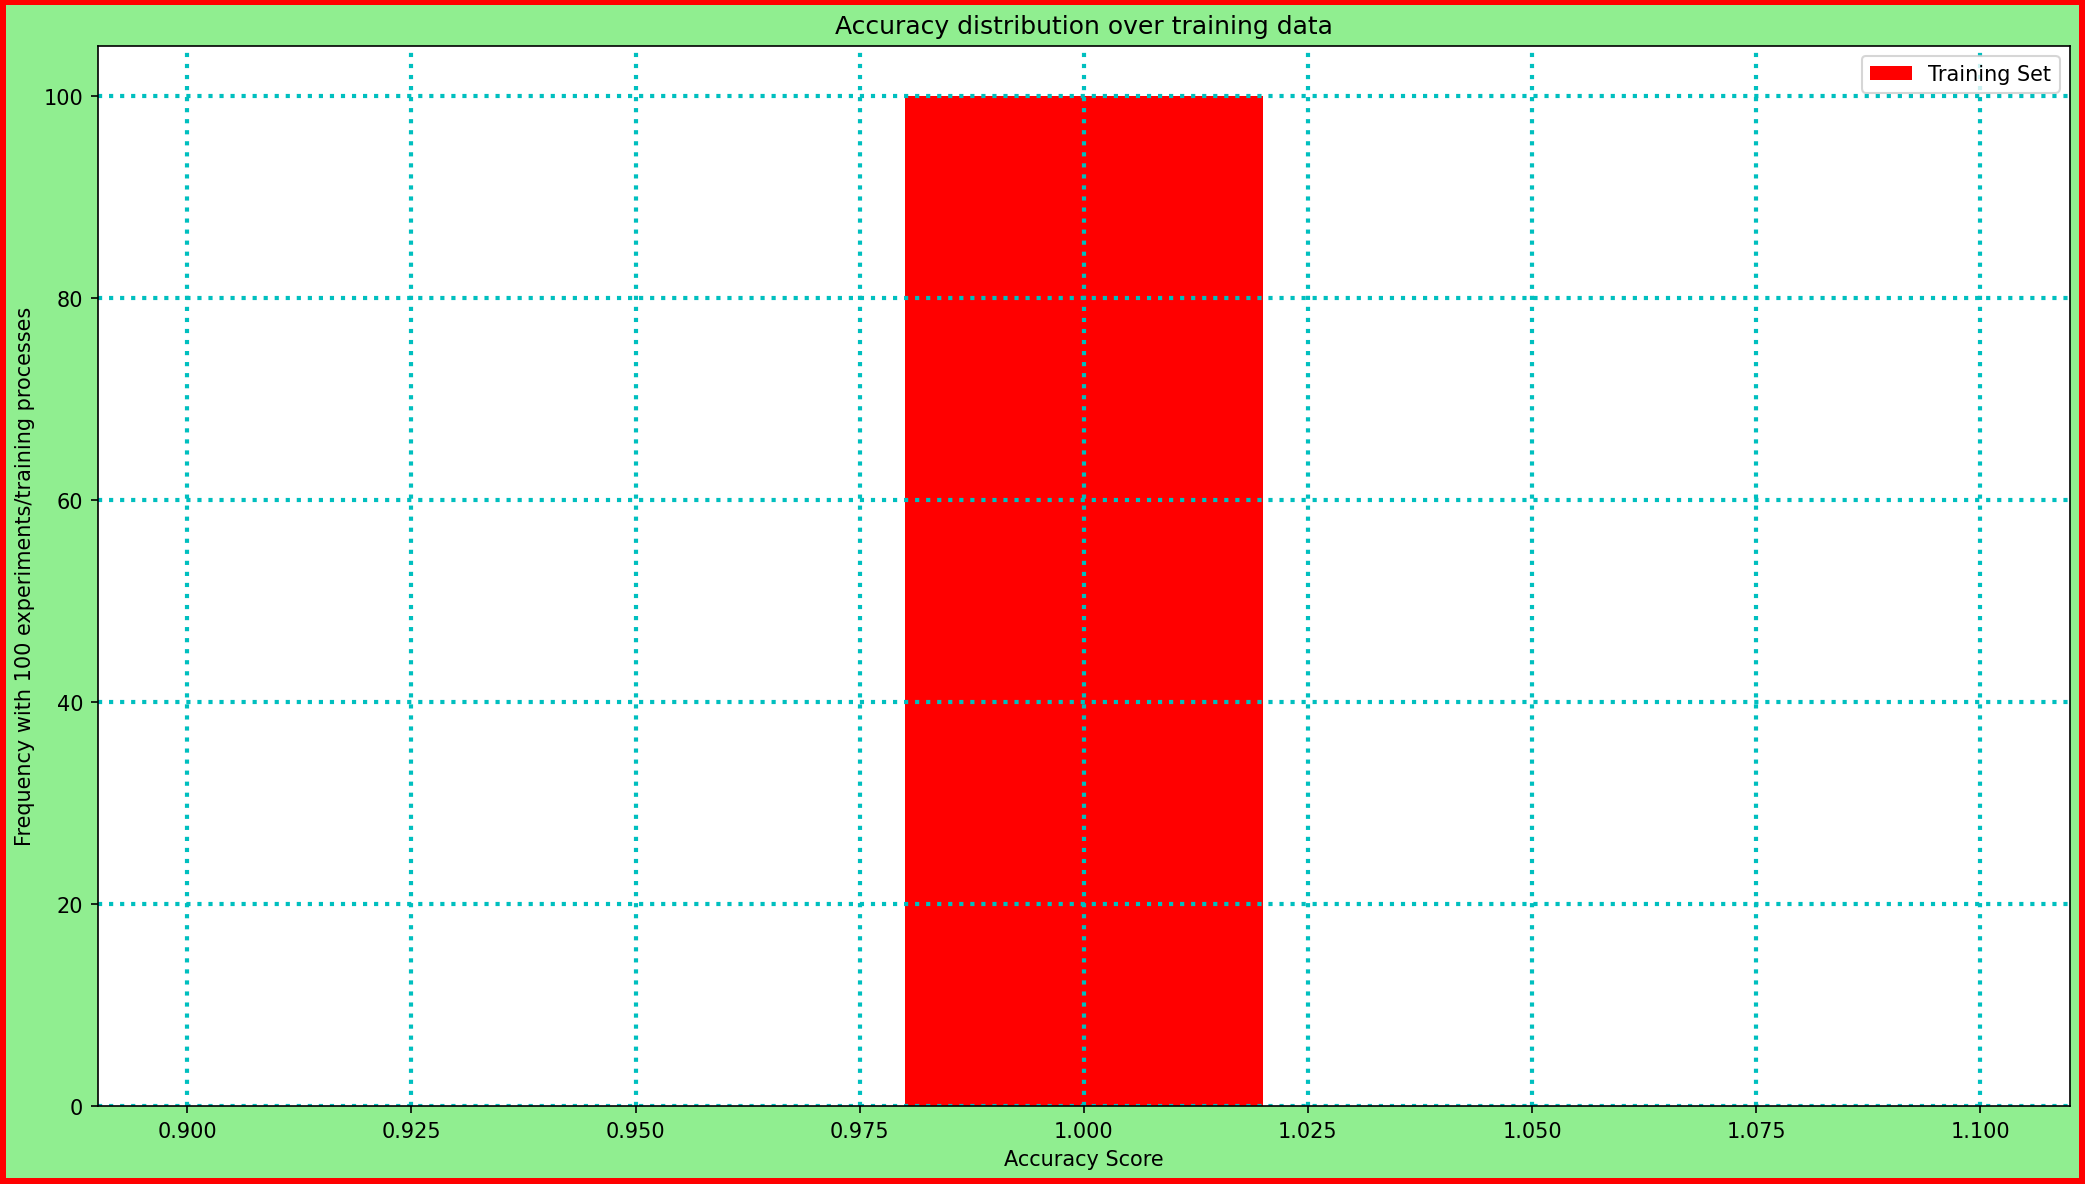

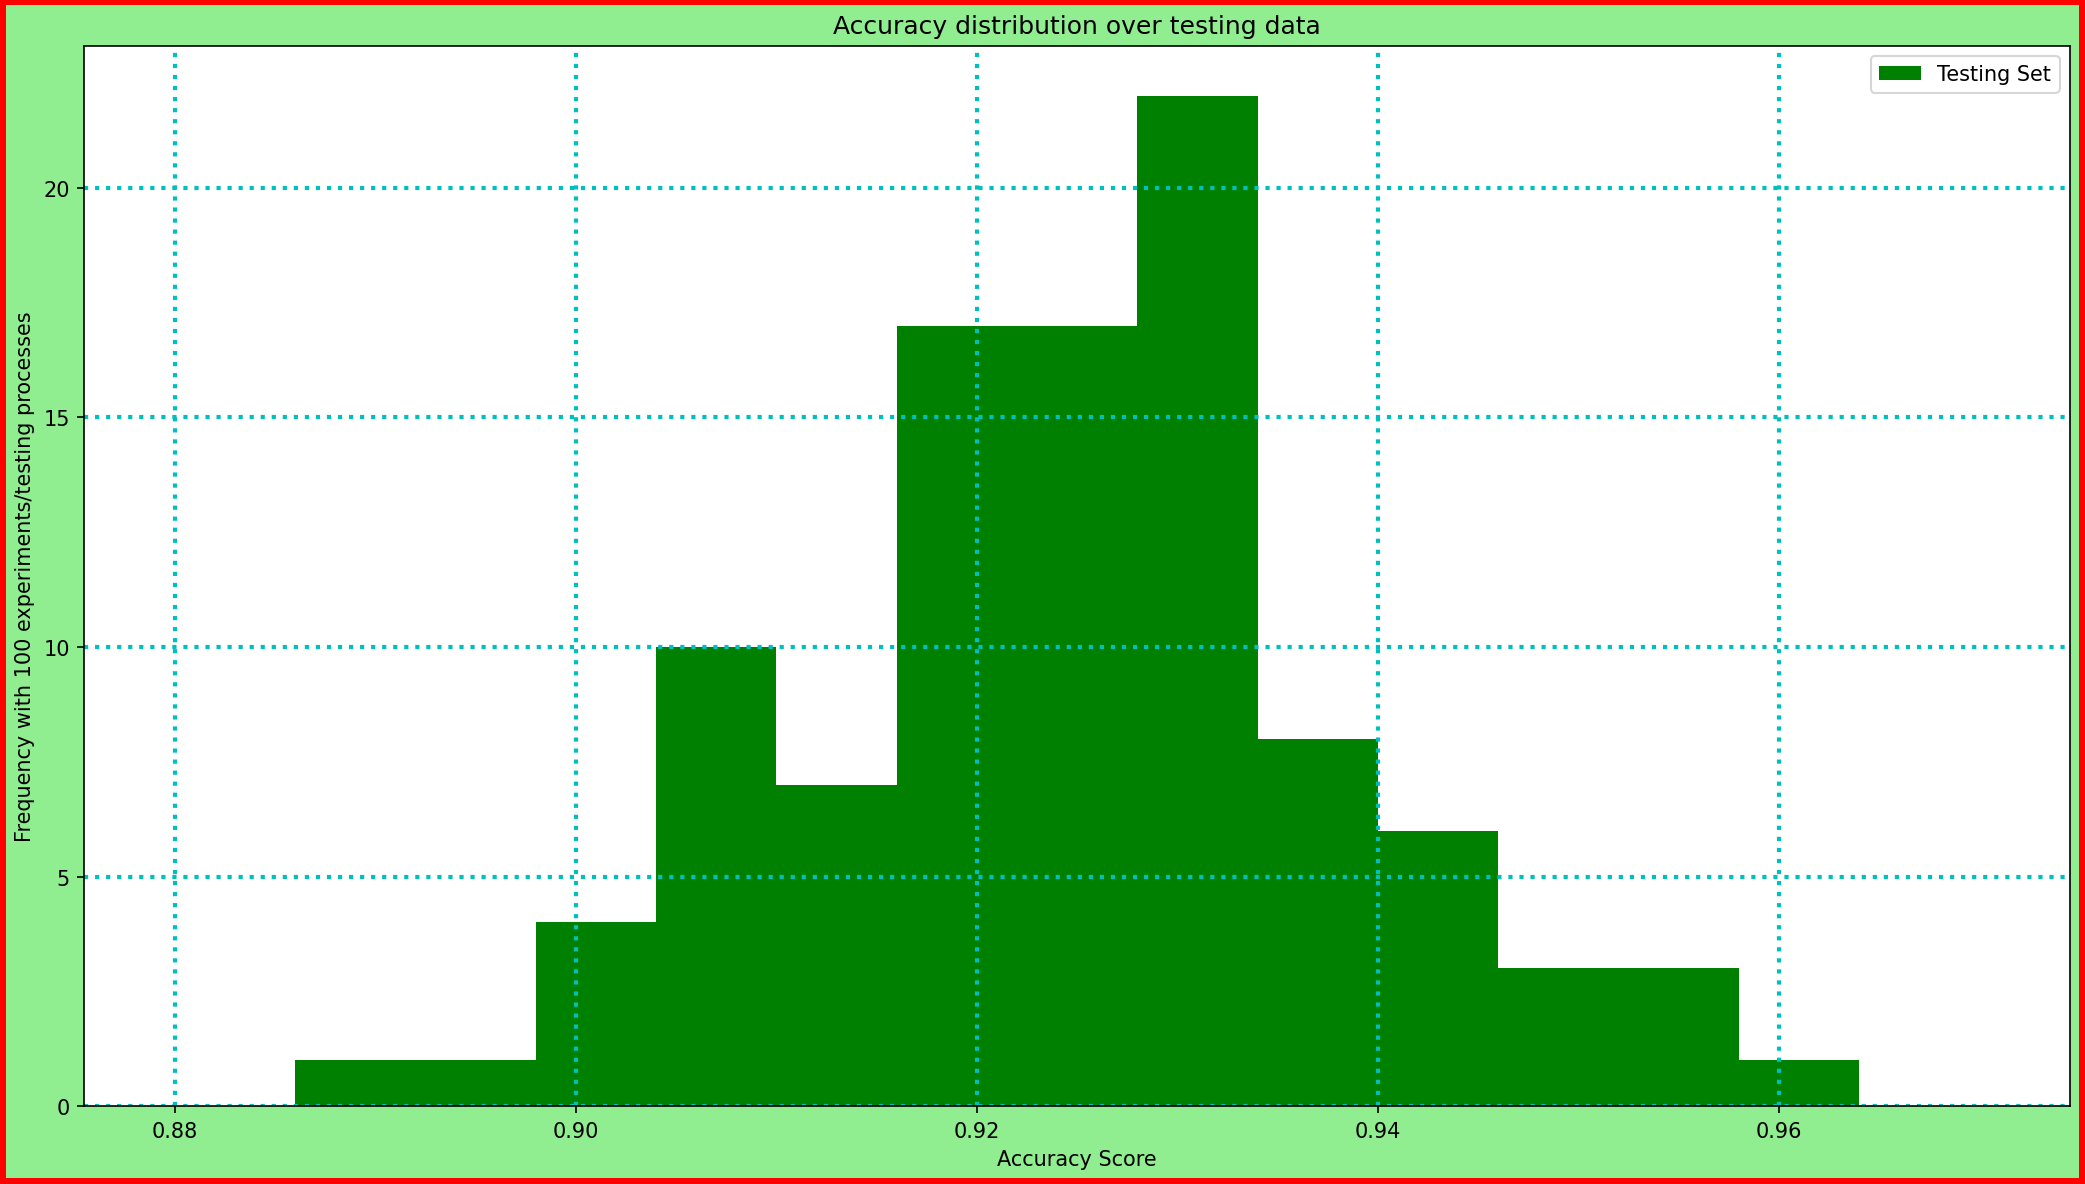

Total training accuracies collected: 100
First 5 results: [1.0, 1.0, 1.0, 1.0, 1.0]
Type of data: <class 'float'>


In [356]:
train_accs, test_accs = run_100_histograms(car_dataset, "class")

In [364]:
import numpy as np

mean_train = np.mean(train_accs)
std_train = np.std(train_accs)

mean_test = np.mean(test_accs)
std_test = np.std(test_accs)

print(f"Question 2.1: Training Data - Mean Accuracy and Standard Deviation")
print(f"Mean Accuracy of Training Data: {mean_train:.6f}")
print(f"Standard Deviation of Training Data: {std_train:.6f}")

print(f"\nQuestion 2.2: Testing Data - Mean Accuracy and Standard Deviation")
print(f"Mean Accuracy of Testing Data: {mean_test:.6f}")
print(f"Standard Deviation of Testing Data: {std_test:.6f}")

Question 2.1: Training Data - Mean Accuracy and Standard Deviation
Mean Accuracy of Training Data: 1.000000
Standard Deviation of Training Data: 0.000000

Question 2.2: Testing Data - Mean Accuracy and Standard Deviation
Mean Accuracy of Testing Data: 0.925347
Standard Deviation of Testing Data: 0.014323
